In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Load the old CNN

In [2]:
# Use metal performance shaders (MPS) if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

#Load the model and configure for the device


model_path = "Models/Model_Exec_711_Epoch_150_cpu_portable_full.pt"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")



Usando dispositivo: mps
Modelo cargado correctamente


# Capture the tensor and get the vector

In [3]:
#Tensor from model to vector[1024] extracter:

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Create the clinical vector

In [4]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [5]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro_od.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 9)
['id', 'OD', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,OD,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [6]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion, od):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Normalizar OD
    try:
        od = float(str(od).strip())
    except ValueError:
        raise ValueError(f"OD no válido: {od}")

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
        + [od]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [7]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
    "Pulpitis Reversible": 6,
}

In [8]:
from pathlib import Path

def normalize_image_key(path):
    path = str(path).strip()

    # Unificar separadores
    path = path.replace("\\", "/")

    # Quitar prefijos posibles
    prefixes = [
        "DataSet/",
        "radiografia_dataset_original/",
        "DataSet/radiografia_dataset_original/",
    ]

    for prefix in prefixes:
        if path.startswith(prefix):
            path = path[len(prefix):]

    return path.strip("/")

# Data Loader

In [9]:
# Check the images
from pathlib import Path

def build_image_path_dict(root_dir, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    image_path_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))
                relative_key = normalize_image_key(relative_key)

                image_path_dict[relative_key] = str(file_path)

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return image_path_dict, failed_files

In [10]:
%pwd

'/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/AddVar'

In [11]:
# Build the image path dictionary
root_dir = "DataSet/radiografia_dataset_original"

image_path_dict, failed_files = build_image_path_dict(
    root_dir=root_dir
)

print("Número de imágenes indexadas:", len(image_path_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(image_path_dict.keys())[:10]

for k in first_keys:
    print("Clave:", k)
    print("Ruta:", image_path_dict[k])
    print()

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de imágenes indexadas: 366
Número de archivos con error: 0
Clave: Necrosis Pulpar/1. OD 36.jpeg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/1. OD 36.jpeg

Clave: Necrosis Pulpar/10. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/10. OD 16.jpg

Clave: Necrosis Pulpar/100. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/100. OD 16.jpg

Clave: Necrosis Pulpar/11. OD 17.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/11. OD 17.jpg

Clave: Necrosis Pulpar/12. OD 46.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/12. OD 46.jpg

Clave: Necrosis Pulpar/13. OD 14.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/13. OD 14.jpg

Clave: Necrosis Pulpar/14. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/14. OD 16.jpg

Clave: Necrosis Pulpar/15. OD 13.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/15. OD 13.jpg

Clave: Necrosis Pulpar/16. OD 36.jpg
Ruta: D

In [12]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in image_path_dict:
            raise KeyError(f"No se encontró imagen para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
            od=row["OD"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "image_path": image_path_dict[image_key],  
            "clinical_vector": clinical_vector,         # [12]
            "label": label,                             # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 364
Errores: 1
Fila: 321
id: 26. OD 21
external_id: Previamente iniciado/26. OD 21.jpg
Clase: Previamente iniciado
Dx Periapical: Tejidos apicales normales
Sensibilidad: negativo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Previamente iniciado/26. OD 21.jpg'


In [13]:
# Data set Class for the stratification
from torch.utils.data import Dataset
from PIL import Image
import torch

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [14]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [15]:
# Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [16]:
# Use the Data loader
def load_data_module(
    samples,
    batch_size=64,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0
):
    ds = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform
    )

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [17]:
# Functions to show the distribution of classes in each split
from collections import Counter

def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_data_module_summary(data_module, class_to_idx):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

    all_idx = np.concatenate([train_idx, val_idx, test_idx])
    print("¿Índices únicos?", len(all_idx) == len(set(all_idx)))
    print("¿Algún índice fuera de rango?", max(all_idx) >= len(ds))
    

In [18]:
#Show the distribution of classes in each split
data_module = load_data_module(samples, num_workers=0)

print_data_module_summary(data_module, class_to_idx)

Counts: 254 55 55

TRAIN total = 254
  Necrosis Pulpar                      70  (27.56%)
  Previamente iniciado                 17  ( 6.69%)
  Previamente Tratado                  30  (11.81%)
  Pulpa Normal                         43  (16.93%)
  Pulpitis Irreversible Asintomática   39  (15.35%)
  Pulpitis Irreversible Sintomática    52  (20.47%)
  Pulpitis Reversible                   3  ( 1.18%)

VAL total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   6  (10.91%)
  Pulpa Normal                          9  (16.36%)
  Pulpitis Irreversible Asintomática    9  (16.36%)
  Pulpitis Irreversible Sintomática    11  (20.00%)
  Pulpitis Reversible                   1  ( 1.82%)

TEST total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   7  (12.73%)
  Pulpa Normal                          9  (16

# Create the new model

In [19]:
import torch
import torch.nn as nn

class FusedClassifier(nn.Module):
    def __init__(
        self,
        input_dim=18444,
        num_classes=6,
        dropout=0.2,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2), 
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),  
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [20]:
#Create the full model

class FullMultimodalDentalDeppGAModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)         
        x = torch.cat([embedding, clinical_vector], dim=1)  
        logits = self.fused_classifier(x)                    # [B, 7]
        return logits

In [21]:
#Testing if the model exists

clinical_dim = len(samples[0]["clinical_vector"])
num_classes = len(class_to_idx)
embedding_dim = 18432

print("clinical_dim:", clinical_dim)
print("num_classes:", num_classes)

extractor = CNNEmbeddingExtractor(model)

fused_classifier = FusedClassifier(
    input_dim=embedding_dim + clinical_dim,
    num_classes=num_classes,
)

full_model = FullMultimodalDentalDeppGAModel(
    embedding_extractor=extractor,
    fused_classifier=fused_classifier,
).to(device)

print(full_model)

clinical_dim: 12
num_classes: 7
FullMultimodalDentalDeppGAModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
      (1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (3): Sequential(
        (0): Conv2d(16, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [22]:
#Testing if the model can process a batch of data

train_loader = data_module["loaders"]["train"]

images, clinical_vectors, labels = next(iter(train_loader))

images = images.to(device)
clinical_vectors = clinical_vectors.to(device)
labels = labels.to(device)

with torch.no_grad():
    embedding = full_model.embedding_extractor(images)
    outputs = full_model(images, clinical_vectors)

print("images:", images.shape)
print("clinical_vectors:", clinical_vectors.shape)
print("embedding:", embedding.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


images: torch.Size([64, 1, 128, 128])
clinical_vectors: torch.Size([64, 12])
embedding: torch.Size([64, 18432])
labels: torch.Size([64])
outputs: torch.Size([64, 7])


In [23]:
images, clinical_vectors, labels = next(iter(train_loader))
print("labels en el batch:", labels)
print("unique labels:", labels.unique())
print("clinical_vectors muestra:", clinical_vectors[0])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


labels en el batch: tensor([2, 0, 2, 0, 4, 0, 3, 0, 5, 5, 0, 5, 5, 1, 2, 1, 5, 0, 5, 3, 4, 5, 4, 1,
        1, 2, 5, 2, 6, 0, 2, 0, 4, 0, 2, 5, 5, 0, 0, 4, 0, 0, 0, 1, 3, 4, 4, 5,
        3, 6, 5, 0, 4, 5, 5, 3, 3, 3, 3, 5, 3, 5, 2, 3])
unique labels: tensor([0, 1, 2, 3, 4, 5, 6])
clinical_vectors muestra: tensor([ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., 12.])


# Training the Full Model

In [24]:
import torch
import torch.nn as nn
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

if device.type == "mps":
    torch.set_float32_matmul_precision("high")
    print("MPS disponible")
else:
    print("Usando:", device)

full_model = full_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
        {"params": full_model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": full_model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

MPS disponible


In [25]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, clinical_vectors, labels in loader:
        images = images.to(device)
        clinical_vectors = clinical_vectors.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images, clinical_vectors)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_total = labels.size(0)
        running_loss += loss.item() * batch_total
        correct += (preds == labels).sum().item()
        total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [26]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    full_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


train_loss = 1.8151
train_acc  = 0.2244


In [27]:
def evaluate_one_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, clinical_vectors, labels in loader:
            images = images.to(device)
            clinical_vectors = clinical_vectors.to(device)
            labels = labels.to(device)

            outputs = model(images, clinical_vectors)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_total = labels.size(0)
            running_loss += loss.item() * batch_total
            correct += (preds == labels).sum().item()
            total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [28]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    min_acc_delta=0.01,
):
    best_model_wts = copy.deepcopy(model.state_dict())

    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_epoch = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    scaler = torch.amp.GradScaler("mps") if device.type == "mps" else None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        acc_improved = val_acc > best_val_acc + min_acc_delta
        acc_similar_but_loss_better = (
            abs(val_acc - best_val_acc) <= min_acc_delta
            and val_loss < best_val_loss
        )

        if acc_improved or acc_similar_but_loss_better:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            print(
                f"  ✅ Nuevo mejor modelo | "
                f"Epoch {best_epoch} | "
                f"Val Acc: {best_val_acc:.4f} | "
                f"Val Loss: {best_val_loss:.4f}"
            )

    model.load_state_dict(best_model_wts)

    print("\nMejor modelo:")
    print(f"Epoch: {best_epoch}")
    print(f"Val Acc: {best_val_acc:.4f}")
    print(f"Val Loss: {best_val_loss:.4f}")

    return model, history

In [29]:
train_loader = data_module["loaders"]["train"]
val_loader = data_module["loaders"]["val"]

#train_full_model, history = train_model(
#    model=full_model,
#    train_loader=train_loader,
#    val_loader=val_loader,
#    criterion=criterion,
#    optimizer=optimizer,
#    device=device,
#    epochs=50,
#)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [31]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
    #model=train_full_model,
    model=full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.1636
Precision macro    : 0.0389
Recall macro       : 0.0966
F1 macro           : 0.0551
Precision weighted : 0.0630
Recall weighted    : 0.1636
F1 weighted        : 0.0906

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.20      0.53      0.29        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.08      0.14      0.10         7
                      Pulpa Normal       0.00      0.00      0.00         9
Pulpitis Irreversible Asintomática       0.00      0.00      0.00         8
 Pulpitis Irreversible Sintomática       0.00      0.00      0.00        11
               Pulpitis Reversible       0.00      0.00      0.00         1

                          accuracy                           0.16        55
                         macro avg       0.04      0.10      0.06        55
                 

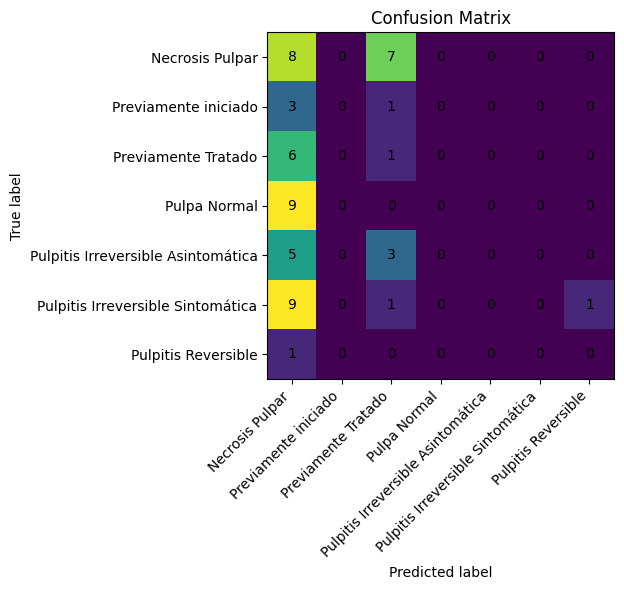

In [32]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


# Combinations of the Colums

In [33]:
from itertools import combinations

clinical_columns = [
    "Dx Periapical",
    "Sensibilidad",
    "Percusión",
    "Movilidad",
    "Palpación",
    "OD",
]

clinical_combinations = []

for r in range(1, len(clinical_columns) + 1):
    clinical_combinations.extend(combinations(clinical_columns, r))

clinical_combinations = [tuple(c) for c in clinical_combinations]

print("Total combinaciones:", len(clinical_combinations))

for i, combo in enumerate(clinical_combinations, start=1):
    print(i, combo)

Total combinaciones: 63
1 ('Dx Periapical',)
2 ('Sensibilidad',)
3 ('Percusión',)
4 ('Movilidad',)
5 ('Palpación',)
6 ('OD',)
7 ('Dx Periapical', 'Sensibilidad')
8 ('Dx Periapical', 'Percusión')
9 ('Dx Periapical', 'Movilidad')
10 ('Dx Periapical', 'Palpación')
11 ('Dx Periapical', 'OD')
12 ('Sensibilidad', 'Percusión')
13 ('Sensibilidad', 'Movilidad')
14 ('Sensibilidad', 'Palpación')
15 ('Sensibilidad', 'OD')
16 ('Percusión', 'Movilidad')
17 ('Percusión', 'Palpación')
18 ('Percusión', 'OD')
19 ('Movilidad', 'Palpación')
20 ('Movilidad', 'OD')
21 ('Palpación', 'OD')
22 ('Dx Periapical', 'Sensibilidad', 'Percusión')
23 ('Dx Periapical', 'Sensibilidad', 'Movilidad')
24 ('Dx Periapical', 'Sensibilidad', 'Palpación')
25 ('Dx Periapical', 'Sensibilidad', 'OD')
26 ('Dx Periapical', 'Percusión', 'Movilidad')
27 ('Dx Periapical', 'Percusión', 'Palpación')
28 ('Dx Periapical', 'Percusión', 'OD')
29 ('Dx Periapical', 'Movilidad', 'Palpación')
30 ('Dx Periapical', 'Movilidad', 'OD')
31 ('Dx Peria

In [34]:
def build_clinical_vector_by_columns(row, selected_columns):
    vector = []

    # Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],
    }

    for column in selected_columns:

        if column == "Dx Periapical":
            value = str(row["Dx Periapical"]).strip()

            if value not in dx_map:
                raise ValueError(f"Dx Periapical no válido: {value}")

            vector.extend(dx_map[value])

        elif column == "Sensibilidad":
            value = str(row["Sensibilidad"]).strip().lower()

            if value not in bin_map:
                raise ValueError(f"Sensibilidad no válida: {value}")

            vector.append(bin_map[value])

        elif column == "Percusión":
            value = str(row["Percusión"]).strip().lower()

            if value not in bin_map:
                raise ValueError(f"Percusión no válida: {value}")

            vector.append(bin_map[value])

        elif column == "Movilidad":
            value = str(row["Movilidad"]).strip()

            if value not in movilidad_map:
                raise ValueError(f"Movilidad no válida: {value}")

            vector.extend(movilidad_map[value])

        elif column == "Palpación":
            value = str(row["Palpación"]).strip().lower()

            if value not in bin_map:
                raise ValueError(f"Palpación no válida: {value}")

            vector.append(bin_map[value])

        elif column == "OD":
            value = str(row["OD"]).strip()

            try:
                value = float(value)
            except ValueError:
                raise ValueError(f"OD no válido: {value}")

            vector.append(value)

        else:
            raise ValueError(f"Columna clínica no reconocida: {column}")

    return torch.tensor(vector, dtype=torch.float32)

In [35]:
def create_samples_for_combination(selected_columns):
    combo_samples = []
    combo_errors = []

    for idx, row in df.iterrows():
        try:
            image_key = normalize_image_key(row["external_id"])

            if image_key not in image_path_dict:
                raise KeyError(f"No se encontró imagen para: {image_key}")

            clinical_vector = build_clinical_vector_by_columns(
                row=row,
                selected_columns=selected_columns,
            )

            if row["Clase"] not in class_to_idx:
                raise KeyError(f"Clase no válida: {row['Clase']}")

            label = class_to_idx[row["Clase"]]

            combo_samples.append({
                "image_key": image_key,
                "image_path": image_path_dict[image_key],
                "clinical_vector": clinical_vector,
                "label": label,
            })

        except Exception as e:
            combo_errors.append({
                "row_idx": idx,
                "id": row.get("id", None),
                "external_id": row.get("external_id", None),
                "clase": row.get("Clase", None),
                "selected_columns": selected_columns,
                "error": str(e),
            })

    return combo_samples, combo_errors

In [36]:
test_combo = (
    "Dx Periapical",
    "Sensibilidad",
    "Movilidad",
    "Palpación",
)

combo_samples, combo_errors = create_samples_for_combination(test_combo)

print("Combinación:", test_combo)
print("Samples válidos:", len(combo_samples))
print("Errores:", len(combo_errors))
print("Tamaño vector clínico:", len(combo_samples[0]["clinical_vector"]))

if combo_errors:
    print(combo_errors[:5])

Combinación: ('Dx Periapical', 'Sensibilidad', 'Movilidad', 'Palpación')
Samples válidos: 364
Errores: 1
Tamaño vector clínico: 10
[{'row_idx': 321, 'id': '26. OD 21', 'external_id': 'Previamente iniciado/26. OD 21.jpg', 'clase': 'Previamente iniciado', 'selected_columns': ('Dx Periapical', 'Sensibilidad', 'Movilidad', 'Palpación'), 'error': "'No se encontró imagen para: Previamente iniciado/26. OD 21.jpg'"}]


In [37]:
test_combo = ("OD",)

combo_samples, combo_errors = create_samples_for_combination(test_combo)

print("Combinación:", test_combo)
print("Samples válidos:", len(combo_samples))
print("Errores:", len(combo_errors))
print("Tamaño vector clínico:", len(combo_samples[0]["clinical_vector"]))

Combinación: ('OD',)
Samples válidos: 364
Errores: 1
Tamaño vector clínico: 1


In [38]:
import copy
import pandas as pd

def build_model_for_clinical_dim(clinical_dim):
    embedding_dim = 18432
    input_dim = embedding_dim + clinical_dim

    fresh_extractor = copy.deepcopy(extractor)

    fused_classifier = FusedClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
    )

    model = FullMultimodalDentalDeppGAModel(
        embedding_extractor=fresh_extractor,
        fused_classifier=fused_classifier,
    ).to(device)

    return model

In [39]:
combination_results = {}

def run_combination_experiment(
    selected_columns,
    batch_size=64,
    epochs=50,
    val_split=0.15,
    test_split=0.15,
    seed=42,
):
    print("\n" + "=" * 80)
    print("Combinación:", selected_columns)
    print("=" * 80)

    combo_samples, combo_errors = create_samples_for_combination(selected_columns)

    if len(combo_samples) == 0:
        raise ValueError(f"No hay samples válidos para {selected_columns}")

    clinical_dim = len(combo_samples[0]["clinical_vector"])
    print("Samples:", len(combo_samples))
    print("Errores:", len(combo_errors))
    print("Clinical dim:", clinical_dim)

    combo_data_module = load_data_module(
        samples=combo_samples,
        batch_size=batch_size,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
        num_workers=0,
    )

    model = build_model_for_clinical_dim(clinical_dim)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW([
        {"params": model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

    trained_model, history = train_model(
        model=model,
        train_loader=combo_data_module["loaders"]["train"],
        val_loader=combo_data_module["loaders"]["val"],
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=epochs,
    )

    results = evaluate_classification_model(
        model=trained_model,
        loader=combo_data_module["loaders"]["test"],
        device=device,
        idx_to_class=idx_to_class,
    )

    print("\nAccuracy:", results["accuracy"])
    print("F1 macro:", results["f1_macro"])
    print("\nClassification report:")
    print(results["classification_report"])

    plot_confusion_matrix(results["confusion_matrix"], idx_to_class)

    key = " + ".join(selected_columns)

    combination_results[key] = {
        "columns": selected_columns,
        "clinical_dim": clinical_dim,
        "samples_count": len(combo_samples),
        "errors": combo_errors,
        "data_module": combo_data_module,
        "model": trained_model,
        "history": history,
        "metrics": results,
    }

    return combination_results[key]

In [40]:
all_combination_results = {}
failed_combination_results = {}

In [41]:
def run_all_combination_experiments(
    clinical_combinations,
    batch_size=64,
    epochs=50,
    val_split=0.15,
    test_split=0.15,
    seed=42,
):
    global all_combination_results
    global failed_combination_results

    total = len(clinical_combinations)

    for i, combo in enumerate(clinical_combinations, start=1):
        key = " + ".join(combo)

        print("\n\n" + "#" * 100)
        print(f"EXPERIMENTO {i}/{total}")
        print(f"Combinación: {key}")
        print("#" * 100)

        try:
            result = run_combination_experiment(
                selected_columns=combo,
                batch_size=batch_size,
                epochs=epochs,
                val_split=val_split,
                test_split=test_split,
                seed=seed,
            )

            all_combination_results[key] = result

        except Exception as e:
            print(f"❌ Error en combinación: {key}")
            print(e)

            failed_combination_results[key] = {
                "columns": combo,
                "error": str(e),
            }

    print("\n" + "=" * 100)
    print("EXPERIMENTOS TERMINADOS")
    print("=" * 100)
    print("Combinaciones exitosas:", len(all_combination_results))
    print("Combinaciones con error:", len(failed_combination_results))

    return all_combination_results



####################################################################################################
EXPERIMENTO 1/63
Combinación: Dx Periapical
####################################################################################################

Combinación: ('Dx Periapical',)
Samples: 364
Errores: 1
Clinical dim: 5


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8771 | Train Acc: 0.2362 | Val Loss: 1.8013 | Val Acc: 0.2545
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2545 | Val Loss: 1.8013
Epoch 02/50 | Train Loss: 1.4604 | Train Acc: 0.4291 | Val Loss: 1.5816 | Val Acc: 0.4182
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.4182 | Val Loss: 1.5816
Epoch 03/50 | Train Loss: 1.1088 | Train Acc: 0.6417 | Val Loss: 1.6571 | Val Acc: 0.3636
Epoch 04/50 | Train Loss: 0.8910 | Train Acc: 0.7008 | Val Loss: 1.4949 | Val Acc: 0.4909
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4909 | Val Loss: 1.4949
Epoch 05/50 | Train Loss: 0.7374 | Train Acc: 0.7638 | Val Loss: 1.2626 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5636 | Val Loss: 1.2626
Epoch 06/50 | Train Loss: 0.6243 | Train Acc: 0.8071 | Val Loss: 1.4015 | Val Acc: 0.5455
Epoch 07/50 | Train Loss: 0.4864 | Train Acc: 0.8740 | Val Loss: 1.2757 | Val Acc: 0.5818
  ✅ Nuevo mejor modelo | Epoch 7 | Val Acc: 0.5818 | Val Loss: 1.2757
Epoch 08/50 | Train 

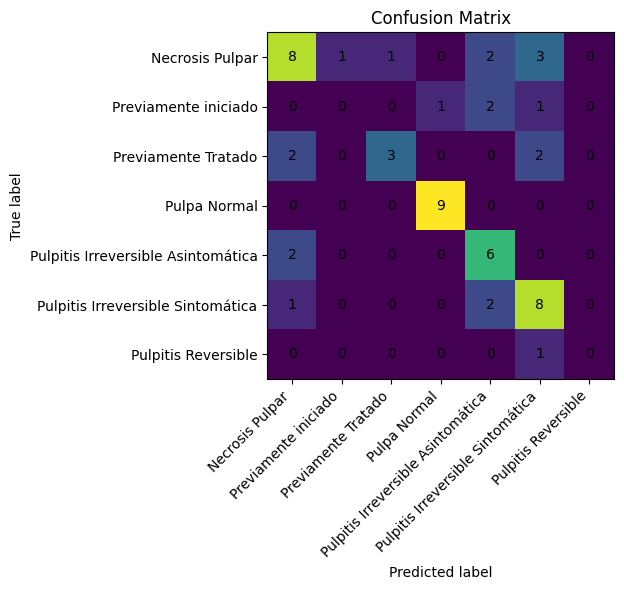



####################################################################################################
EXPERIMENTO 2/63
Combinación: Sensibilidad
####################################################################################################

Combinación: ('Sensibilidad',)
Samples: 364
Errores: 1
Clinical dim: 1


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.9000 | Train Acc: 0.2441 | Val Loss: 1.8961 | Val Acc: 0.3273
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3273 | Val Loss: 1.8961
Epoch 02/50 | Train Loss: 1.3720 | Train Acc: 0.4370 | Val Loss: 1.5508 | Val Acc: 0.3818
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3818 | Val Loss: 1.5508
Epoch 03/50 | Train Loss: 1.1473 | Train Acc: 0.5669 | Val Loss: 1.4762 | Val Acc: 0.4364
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4364 | Val Loss: 1.4762
Epoch 04/50 | Train Loss: 0.9220 | Train Acc: 0.6654 | Val Loss: 1.3557 | Val Acc: 0.5091
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5091 | Val Loss: 1.3557
Epoch 05/50 | Train Loss: 0.7160 | Train Acc: 0.7402 | Val Loss: 1.2843 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5636 | Val Loss: 1.2843
Epoch 06/50 | Train Loss: 0.5887 | Train Acc: 0.8268 | Val Loss: 1.2760 | Val Acc: 0.5273
Epoch 07/50 | Train Loss: 0.5633 | Train Acc: 0.7953 | Val Loss: 1.2056 | Val Acc: 0.5636
  ✅ Nuevo mejor mode

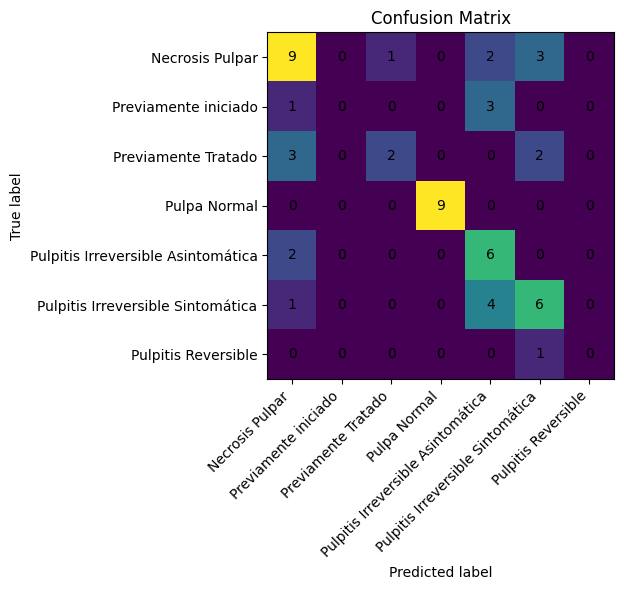



####################################################################################################
EXPERIMENTO 3/63
Combinación: Percusión
####################################################################################################

Combinación: ('Percusión',)
Samples: 364
Errores: 1
Clinical dim: 1


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8771 | Train Acc: 0.2795 | Val Loss: 1.8247 | Val Acc: 0.2364
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2364 | Val Loss: 1.8247
Epoch 02/50 | Train Loss: 1.5117 | Train Acc: 0.4528 | Val Loss: 1.5869 | Val Acc: 0.3273
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3273 | Val Loss: 1.5869
Epoch 03/50 | Train Loss: 1.1886 | Train Acc: 0.6024 | Val Loss: 1.6673 | Val Acc: 0.3273
Epoch 04/50 | Train Loss: 1.0092 | Train Acc: 0.6614 | Val Loss: 1.3931 | Val Acc: 0.4909
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4909 | Val Loss: 1.3931
Epoch 05/50 | Train Loss: 0.8006 | Train Acc: 0.7244 | Val Loss: 1.3672 | Val Acc: 0.5273
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5273 | Val Loss: 1.3672
Epoch 06/50 | Train Loss: 0.6239 | Train Acc: 0.8110 | Val Loss: 1.3481 | Val Acc: 0.4909
Epoch 07/50 | Train Loss: 0.5346 | Train Acc: 0.8425 | Val Loss: 1.2610 | Val Acc: 0.6000
  ✅ Nuevo mejor modelo | Epoch 7 | Val Acc: 0.6000 | Val Loss: 1.2610
Epoch 08/50 | Train 

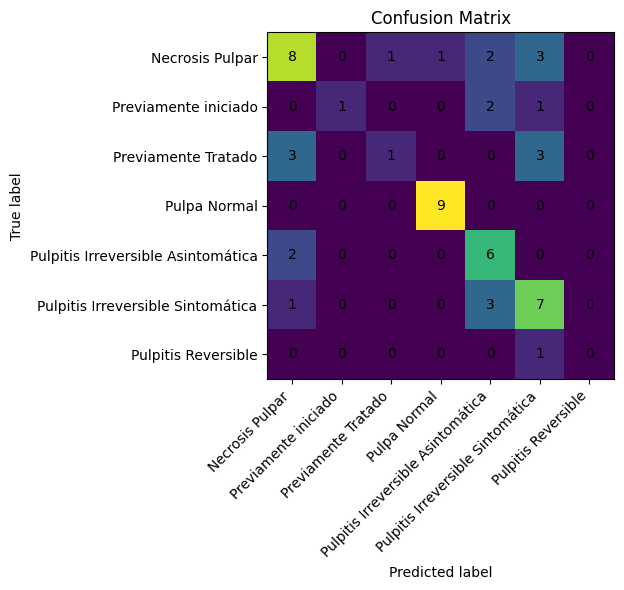



####################################################################################################
EXPERIMENTO 4/63
Combinación: Movilidad
####################################################################################################

Combinación: ('Movilidad',)
Samples: 364
Errores: 1
Clinical dim: 3


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8673 | Train Acc: 0.2126 | Val Loss: 1.7120 | Val Acc: 0.3455
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3455 | Val Loss: 1.7120
Epoch 02/50 | Train Loss: 1.4303 | Train Acc: 0.4921 | Val Loss: 1.5663 | Val Acc: 0.3273
Epoch 03/50 | Train Loss: 1.0805 | Train Acc: 0.6614 | Val Loss: 1.4060 | Val Acc: 0.4909
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4909 | Val Loss: 1.4060
Epoch 04/50 | Train Loss: 0.8206 | Train Acc: 0.7362 | Val Loss: 1.3663 | Val Acc: 0.5091
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5091 | Val Loss: 1.3663
Epoch 05/50 | Train Loss: 0.7030 | Train Acc: 0.7677 | Val Loss: 1.2166 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5636 | Val Loss: 1.2166
Epoch 06/50 | Train Loss: 0.5324 | Train Acc: 0.8504 | Val Loss: 1.1771 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5636 | Val Loss: 1.1771
Epoch 07/50 | Train Loss: 0.4230 | Train Acc: 0.8740 | Val Loss: 1.1658 | Val Acc: 0.5636
  ✅ Nuevo mejor mode

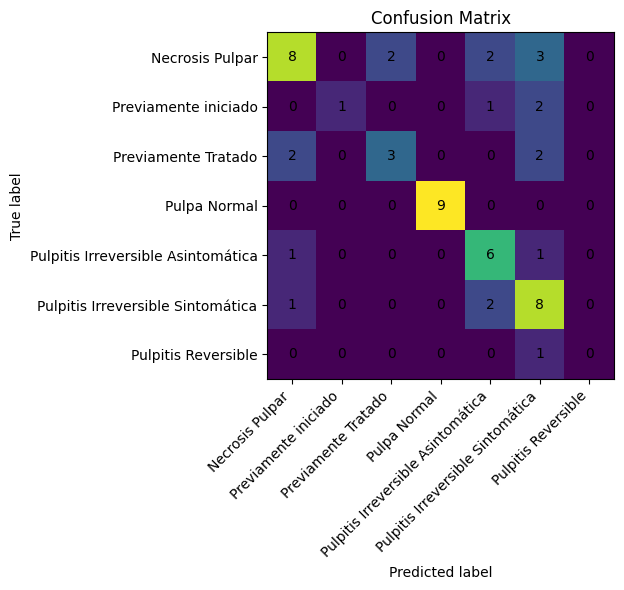



####################################################################################################
EXPERIMENTO 5/63
Combinación: Palpación
####################################################################################################

Combinación: ('Palpación',)
Samples: 364
Errores: 1
Clinical dim: 1


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8586 | Train Acc: 0.2598 | Val Loss: 1.7179 | Val Acc: 0.3091
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3091 | Val Loss: 1.7179
Epoch 02/50 | Train Loss: 1.5044 | Train Acc: 0.3976 | Val Loss: 1.6234 | Val Acc: 0.3818
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3818 | Val Loss: 1.6234
Epoch 03/50 | Train Loss: 1.2327 | Train Acc: 0.5630 | Val Loss: 1.5426 | Val Acc: 0.4545
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4545 | Val Loss: 1.5426
Epoch 04/50 | Train Loss: 1.0016 | Train Acc: 0.6535 | Val Loss: 1.3564 | Val Acc: 0.4909
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4909 | Val Loss: 1.3564
Epoch 05/50 | Train Loss: 0.8326 | Train Acc: 0.7087 | Val Loss: 1.3189 | Val Acc: 0.5273
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5273 | Val Loss: 1.3189
Epoch 06/50 | Train Loss: 0.7242 | Train Acc: 0.7559 | Val Loss: 1.2884 | Val Acc: 0.5455
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5455 | Val Loss: 1.2884
Epoch 07/50 | Train Loss: 0.5487 | Train

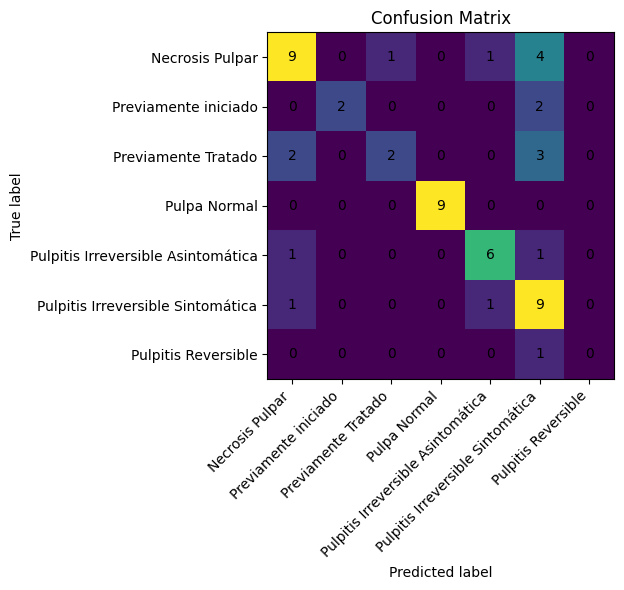



####################################################################################################
EXPERIMENTO 6/63
Combinación: OD
####################################################################################################

Combinación: ('OD',)
Samples: 364
Errores: 1
Clinical dim: 1


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.9118 | Train Acc: 0.2244 | Val Loss: 1.8354 | Val Acc: 0.2727
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2727 | Val Loss: 1.8354
Epoch 02/50 | Train Loss: 1.4983 | Train Acc: 0.4055 | Val Loss: 1.4576 | Val Acc: 0.4000
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.4000 | Val Loss: 1.4576
Epoch 03/50 | Train Loss: 1.1580 | Train Acc: 0.5866 | Val Loss: 1.4901 | Val Acc: 0.4182
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4182 | Val Loss: 1.4901
Epoch 04/50 | Train Loss: 0.9044 | Train Acc: 0.6929 | Val Loss: 1.3885 | Val Acc: 0.5273
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5273 | Val Loss: 1.3885
Epoch 05/50 | Train Loss: 0.7360 | Train Acc: 0.7717 | Val Loss: 1.1910 | Val Acc: 0.5818
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5818 | Val Loss: 1.1910
Epoch 06/50 | Train Loss: 0.6446 | Train Acc: 0.7913 | Val Loss: 1.2278 | Val Acc: 0.5091
Epoch 07/50 | Train Loss: 0.4969 | Train Acc: 0.8268 | Val Loss: 1.2332 | Val Acc: 0.5818
Epoch 08/50 | Train 

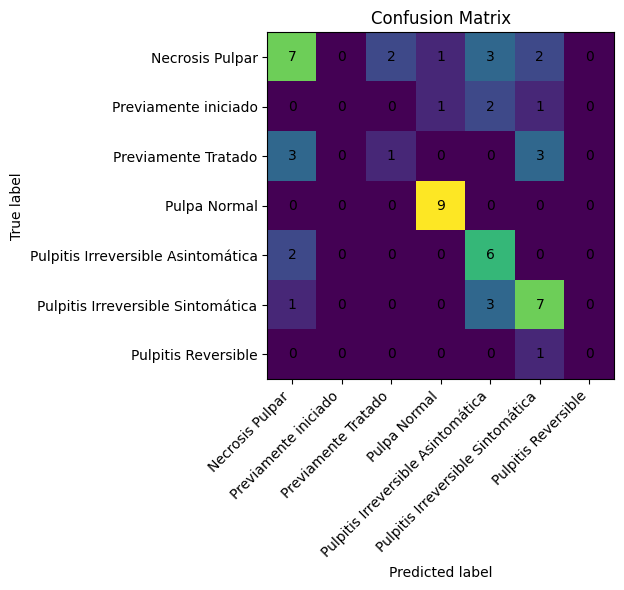



####################################################################################################
EXPERIMENTO 7/63
Combinación: Dx Periapical + Sensibilidad
####################################################################################################

Combinación: ('Dx Periapical', 'Sensibilidad')
Samples: 364
Errores: 1
Clinical dim: 6


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.9014 | Train Acc: 0.2283 | Val Loss: 1.7634 | Val Acc: 0.2182
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2182 | Val Loss: 1.7634
Epoch 02/50 | Train Loss: 1.4690 | Train Acc: 0.4567 | Val Loss: 1.5260 | Val Acc: 0.4000
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.4000 | Val Loss: 1.5260
Epoch 03/50 | Train Loss: 1.1965 | Train Acc: 0.5591 | Val Loss: 1.6181 | Val Acc: 0.3455
Epoch 04/50 | Train Loss: 0.9031 | Train Acc: 0.6850 | Val Loss: 1.3760 | Val Acc: 0.4909
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4909 | Val Loss: 1.3760
Epoch 05/50 | Train Loss: 0.7599 | Train Acc: 0.7323 | Val Loss: 1.2295 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5636 | Val Loss: 1.2295
Epoch 06/50 | Train Loss: 0.6310 | Train Acc: 0.8228 | Val Loss: 1.2505 | Val Acc: 0.5818
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5818 | Val Loss: 1.2505
Epoch 07/50 | Train Loss: 0.4938 | Train Acc: 0.8425 | Val Loss: 1.2169 | Val Acc: 0.5455
Epoch 08/50 | Train 

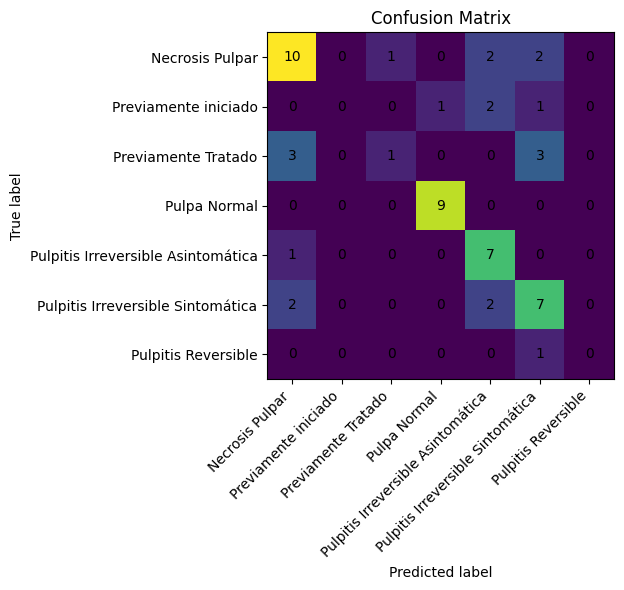



####################################################################################################
EXPERIMENTO 8/63
Combinación: Dx Periapical + Percusión
####################################################################################################

Combinación: ('Dx Periapical', 'Percusión')
Samples: 364
Errores: 1
Clinical dim: 6


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8504 | Train Acc: 0.2087 | Val Loss: 1.7582 | Val Acc: 0.3636
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3636 | Val Loss: 1.7582
Epoch 02/50 | Train Loss: 1.3769 | Train Acc: 0.4764 | Val Loss: 1.5764 | Val Acc: 0.3636
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3636 | Val Loss: 1.5764
Epoch 03/50 | Train Loss: 1.1310 | Train Acc: 0.5866 | Val Loss: 1.5569 | Val Acc: 0.3636
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.3636 | Val Loss: 1.5569
Epoch 04/50 | Train Loss: 0.8621 | Train Acc: 0.7008 | Val Loss: 1.4411 | Val Acc: 0.5273
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5273 | Val Loss: 1.4411
Epoch 05/50 | Train Loss: 0.7680 | Train Acc: 0.7323 | Val Loss: 1.2498 | Val Acc: 0.5273
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5273 | Val Loss: 1.2498
Epoch 06/50 | Train Loss: 0.5942 | Train Acc: 0.8110 | Val Loss: 1.2868 | Val Acc: 0.5273
Epoch 07/50 | Train Loss: 0.4411 | Train Acc: 0.8740 | Val Loss: 1.2232 | Val Acc: 0.6000
  ✅ Nuevo mejor mode

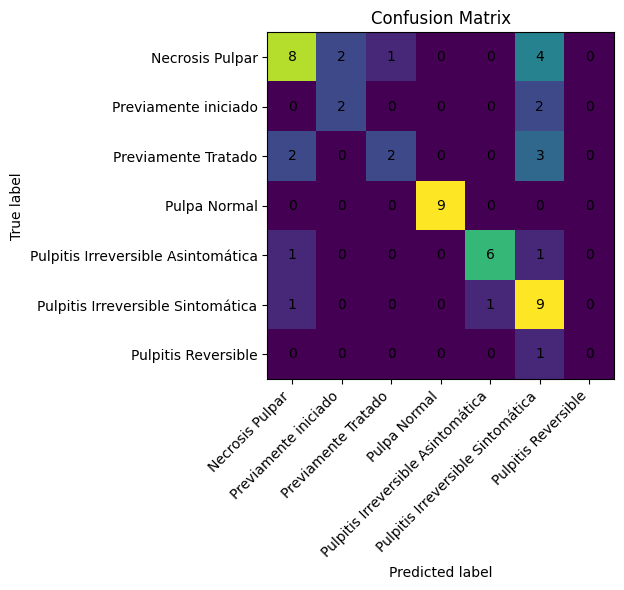



####################################################################################################
EXPERIMENTO 9/63
Combinación: Dx Periapical + Movilidad
####################################################################################################

Combinación: ('Dx Periapical', 'Movilidad')
Samples: 364
Errores: 1
Clinical dim: 8


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8988 | Train Acc: 0.3150 | Val Loss: 1.8221 | Val Acc: 0.3818
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3818 | Val Loss: 1.8221
Epoch 02/50 | Train Loss: 1.5804 | Train Acc: 0.4409 | Val Loss: 1.6799 | Val Acc: 0.3273
Epoch 03/50 | Train Loss: 1.3165 | Train Acc: 0.5591 | Val Loss: 1.5025 | Val Acc: 0.4364
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4364 | Val Loss: 1.5025
Epoch 04/50 | Train Loss: 1.0430 | Train Acc: 0.6496 | Val Loss: 1.4707 | Val Acc: 0.4909
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4909 | Val Loss: 1.4707
Epoch 05/50 | Train Loss: 0.8518 | Train Acc: 0.7008 | Val Loss: 1.3114 | Val Acc: 0.5091
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5091 | Val Loss: 1.3114
Epoch 06/50 | Train Loss: 0.7301 | Train Acc: 0.7480 | Val Loss: 1.2806 | Val Acc: 0.5273
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5273 | Val Loss: 1.2806
Epoch 07/50 | Train Loss: 0.5842 | Train Acc: 0.8110 | Val Loss: 1.2735 | Val Acc: 0.5636
  ✅ Nuevo mejor mode

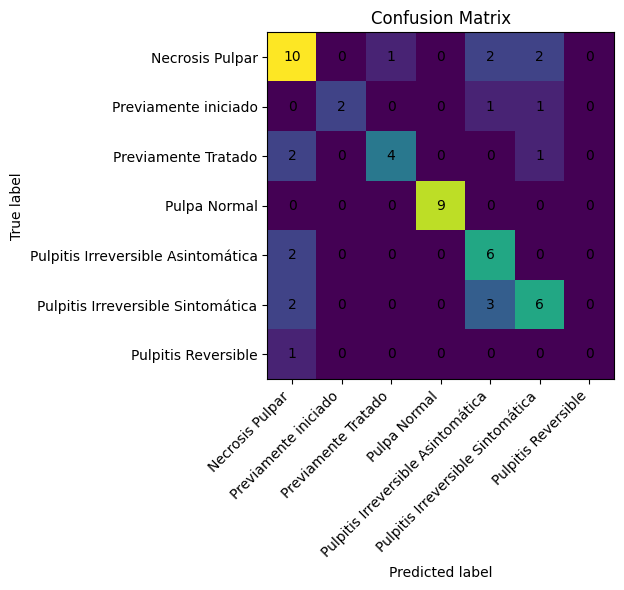



####################################################################################################
EXPERIMENTO 10/63
Combinación: Dx Periapical + Palpación
####################################################################################################

Combinación: ('Dx Periapical', 'Palpación')
Samples: 364
Errores: 1
Clinical dim: 6


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8460 | Train Acc: 0.2008 | Val Loss: 1.8634 | Val Acc: 0.3818
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3818 | Val Loss: 1.8634
Epoch 02/50 | Train Loss: 1.4175 | Train Acc: 0.4567 | Val Loss: 1.8828 | Val Acc: 0.3091
Epoch 03/50 | Train Loss: 1.1886 | Train Acc: 0.5787 | Val Loss: 1.4783 | Val Acc: 0.4000
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4000 | Val Loss: 1.4783
Epoch 04/50 | Train Loss: 0.9201 | Train Acc: 0.7087 | Val Loss: 1.3939 | Val Acc: 0.4727
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4727 | Val Loss: 1.3939
Epoch 05/50 | Train Loss: 0.7759 | Train Acc: 0.7638 | Val Loss: 1.2697 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5636 | Val Loss: 1.2697
Epoch 06/50 | Train Loss: 0.5903 | Train Acc: 0.8307 | Val Loss: 1.2612 | Val Acc: 0.6000
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.6000 | Val Loss: 1.2612
Epoch 07/50 | Train Loss: 0.5076 | Train Acc: 0.8268 | Val Loss: 1.2793 | Val Acc: 0.5636
Epoch 08/50 | Train 

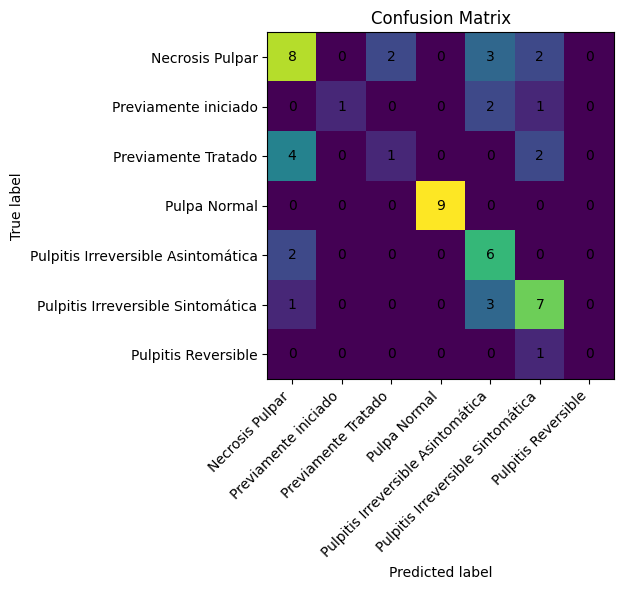



####################################################################################################
EXPERIMENTO 11/63
Combinación: Dx Periapical + OD
####################################################################################################

Combinación: ('Dx Periapical', 'OD')
Samples: 364
Errores: 1
Clinical dim: 6


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.9315 | Train Acc: 0.2362 | Val Loss: 1.8700 | Val Acc: 0.3091
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3091 | Val Loss: 1.8700
Epoch 02/50 | Train Loss: 1.4862 | Train Acc: 0.4291 | Val Loss: 1.5368 | Val Acc: 0.4364
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.4364 | Val Loss: 1.5368
Epoch 03/50 | Train Loss: 1.2827 | Train Acc: 0.5315 | Val Loss: 1.7101 | Val Acc: 0.3636
Epoch 04/50 | Train Loss: 1.0768 | Train Acc: 0.5866 | Val Loss: 1.4709 | Val Acc: 0.4545
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4545 | Val Loss: 1.4709
Epoch 05/50 | Train Loss: 0.9136 | Train Acc: 0.6732 | Val Loss: 1.3264 | Val Acc: 0.5455
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5455 | Val Loss: 1.3264
Epoch 06/50 | Train Loss: 0.7962 | Train Acc: 0.7126 | Val Loss: 1.3262 | Val Acc: 0.5455
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5455 | Val Loss: 1.3262
Epoch 07/50 | Train Loss: 0.6673 | Train Acc: 0.7835 | Val Loss: 1.2143 | Val Acc: 0.5273
Epoch 08/50 | Train 

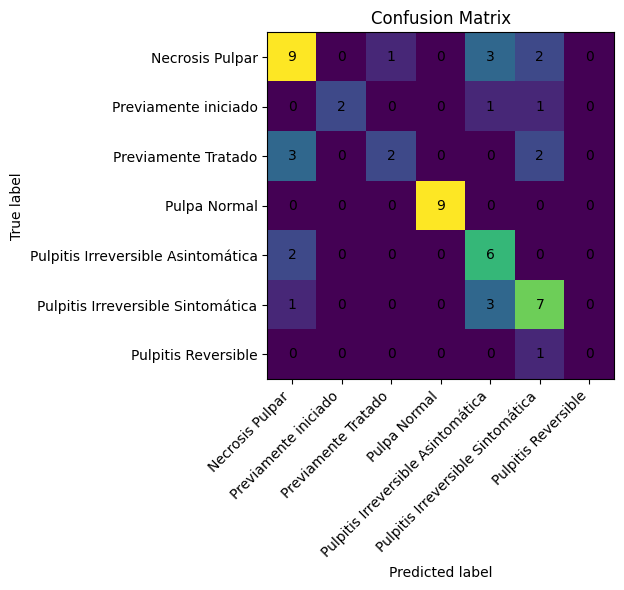



####################################################################################################
EXPERIMENTO 12/63
Combinación: Sensibilidad + Percusión
####################################################################################################

Combinación: ('Sensibilidad', 'Percusión')
Samples: 364
Errores: 1
Clinical dim: 2


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8888 | Train Acc: 0.2165 | Val Loss: 1.7029 | Val Acc: 0.4182
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.4182 | Val Loss: 1.7029
Epoch 02/50 | Train Loss: 1.5684 | Train Acc: 0.3661 | Val Loss: 1.6153 | Val Acc: 0.4000
Epoch 03/50 | Train Loss: 1.2745 | Train Acc: 0.5079 | Val Loss: 1.5622 | Val Acc: 0.3636
Epoch 04/50 | Train Loss: 1.0771 | Train Acc: 0.6299 | Val Loss: 1.4204 | Val Acc: 0.5091
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5091 | Val Loss: 1.4204
Epoch 05/50 | Train Loss: 0.9306 | Train Acc: 0.7126 | Val Loss: 1.2878 | Val Acc: 0.5091
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5091 | Val Loss: 1.2878
Epoch 06/50 | Train Loss: 0.7129 | Train Acc: 0.7677 | Val Loss: 1.3295 | Val Acc: 0.5091
Epoch 07/50 | Train Loss: 0.5594 | Train Acc: 0.8307 | Val Loss: 1.2539 | Val Acc: 0.4909
Epoch 08/50 | Train Loss: 0.4801 | Train Acc: 0.8701 | Val Loss: 1.2480 | Val Acc: 0.5636
  ✅ Nuevo mejor modelo | Epoch 8 | Val Acc: 0.5636 | Val Loss: 1.2480


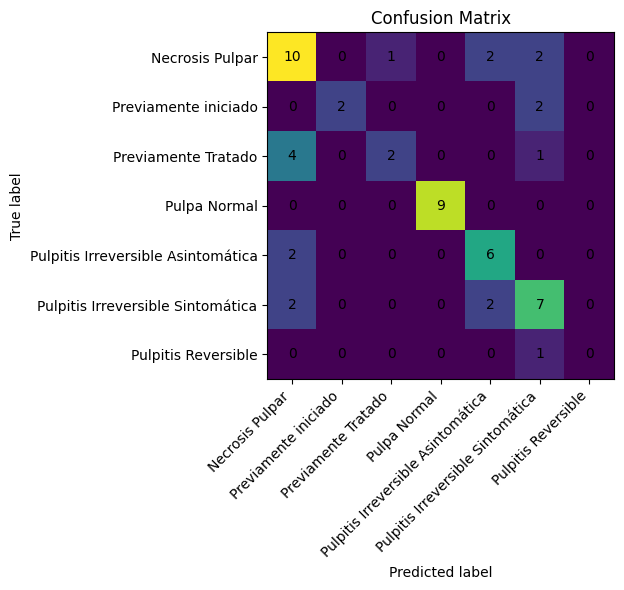



####################################################################################################
EXPERIMENTO 13/63
Combinación: Sensibilidad + Movilidad
####################################################################################################

Combinación: ('Sensibilidad', 'Movilidad')
Samples: 364
Errores: 1
Clinical dim: 4


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_99111/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8951 | Train Acc: 0.2126 | Val Loss: 1.8460 | Val Acc: 0.2909
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2909 | Val Loss: 1.8460
Epoch 02/50 | Train Loss: 1.4340 | Train Acc: 0.4567 | Val Loss: 1.6683 | Val Acc: 0.3818
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3818 | Val Loss: 1.6683
Epoch 03/50 | Train Loss: 1.0822 | Train Acc: 0.5787 | Val Loss: 1.4010 | Val Acc: 0.4182
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4182 | Val Loss: 1.4010
Epoch 04/50 | Train Loss: 0.8714 | Train Acc: 0.7126 | Val Loss: 1.3982 | Val Acc: 0.4727
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4727 | Val Loss: 1.3982
Epoch 05/50 | Train Loss: 0.7022 | Train Acc: 0.7205 | Val Loss: 1.2755 | Val Acc: 0.5818
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5818 | Val Loss: 1.2755
Epoch 06/50 | Train Loss: 0.6042 | Train Acc: 0.7598 | Val Loss: 1.2537 | Val Acc: 0.6182
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.6182 | Val Loss: 1.2537
Epoch 07/50 | Train Loss: 0.5140 | Train

KeyboardInterrupt: 

In [42]:
all_results = run_all_combination_experiments(
    clinical_combinations=clinical_combinations,
    batch_size=64,
    epochs=50,
    val_split=0.15,
    test_split=0.15,
    seed=42,
)

In [ ]:
def build_combination_summary_table(results_dict):
    rows = []

    for key, result in results_dict.items():
        metrics = result["metrics"]

        rows.append({
            "combination": key,
            "num_columns": len(result["columns"]),
            "clinical_dim": result["clinical_dim"],
            "samples_count": result["samples_count"],
            "accuracy": metrics["accuracy"],
            "f1_macro": metrics["f1_macro"],
        })

    summary_df = pd.DataFrame(rows)

    summary_df = summary_df.sort_values(
        by=["f1_macro", "accuracy"],
        ascending=False,
    ).reset_index(drop=True)

    summary_df.insert(0, "rank", range(1, len(summary_df) + 1))

    return summary_df

In [ ]:
summary_df = build_combination_summary_table(all_combination_results)

summary_df

best_row = summary_df.iloc[0]

print("🏆 Mejor combinación")
print("Combinación:", best_row["combination"])
print("Columnas usadas:", best_row["num_columns"])
print("Clinical dim:", best_row["clinical_dim"])
print("Accuracy:", best_row["accuracy"])
print("F1 macro:", best_row["f1_macro"])